In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
def find_project_root(marker=".gitignore"):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

In [3]:
oc = pd.read_parquet(DATA_DIR / "spy_option_chain.parquet")
oc = oc[(oc['date'].dt.day_of_week < 5) & (oc['date'].dt.day_of_week != 1) & (oc['date'].dt.day_of_week != 3)]

oc.head()

,date,act_symbol,expiration,strike,call_put,bid,ask,vol,delta,gamma,theta,vega,rho
66,2020-01-06,SPY,2020-01-21,275.0,Call,48.52,48.75,0.3116,0.9954,0.0006,-0.0213,0.0087,0.1123
67,2020-01-06,SPY,2020-01-21,275.0,Put,0.03,0.04,0.3175,-0.0052,0.0007,-0.0103,0.0098,-0.0007
68,2020-01-06,SPY,2020-01-21,290.0,Call,33.57,33.78,0.2383,0.9891,0.0018,-0.0278,0.0188,0.1176
69,2020-01-06,SPY,2020-01-21,290.0,Put,0.06,0.07,0.2415,-0.0117,0.0019,-0.0160,0.0201,-0.0016
70,2020-01-06,SPY,2020-01-21,301.0,Call,22.69,22.87,0.1939,0.9689,0.0055,-0.0428,0.0460,0.1194


In [4]:
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")

vh = vh.set_index("date").sort_index()
vh = vh.iloc[20:]

vh.head()

,act_symbol,hv_current,hv_week_ago,hv_month_ago,hv_year_high,hv_year_high_date,hv_year_low,hv_year_low_date,iv_current,iv_week_ago,iv_month_ago,iv_year_high,iv_year_high_date,iv_year_low,iv_year_low_date
date,,,,,,,,,,,,,,,
2020-02-21,SPY,0.1207,0.1181,0.0705,0.2084,2019-09-05,0.0549,2019-11-27,0.1476,0.1111,0.1098,0.2259,2019-08-05,0.0886,2019-12-16
2020-02-24,SPY,0.1556,0.1181,0.0725,0.2084,2019-09-05,0.0549,2019-11-27,0.2152,0.1111,0.1269,0.2259,2019-08-05,0.0886,2019-12-16
2020-02-26,SPY,0.1771,0.1159,0.0725,0.2084,2019-09-05,0.0549,2019-11-27,0.2436,0.1212,0.1602,0.2441,2020-02-25,0.0886,2019-12-16
2020-02-28,SPY,0.2180,0.1207,0.0902,0.2186,2020-02-27,0.0549,2019-11-27,0.3651,0.1476,0.1465,0.3651,2020-02-28,0.0886,2019-12-16
2020-03-02,SPY,0.2535,0.1556,0.1049,0.2535,2020-03-02,0.0549,2019-11-27,0.2885,0.2152,0.1615,0.3651,2020-02-28,0.0886,2019-12-16


In [11]:
sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
sp.index.name = 'date'

sp.head()

,Close,High,Low,Open,Volume
date,,,,,
2020-01-02,296.888123,296.906418,294.749676,295.672691,59151200
2020-01-03,294.640106,295.764174,293.442942,293.497772,77709700
2020-01-06,295.764130,295.846374,292.766617,292.885424,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504425,297.719857,294.877741,295.124476,68296000


In [6]:
#Join options data with price data

merged = oc.merge(sp, left_on='date', right_index = True, how='left')
merged = merged.dropna(subset=["Close"])
merged = merged.reset_index(drop=True)

merged.head()

,date,act_symbol,expiration,strike,call_put,bid,ask,vol,delta,gamma,theta,vega,rho,Close,High,Low,Open,Volume
0,2020-01-06,SPY,2020-01-21,275.0,Call,48.52,48.75,0.3116,0.9954,0.0006,-0.0213,0.0087,0.1123,295.76413,295.846374,292.766617,292.885424,55653900.0
1,2020-01-06,SPY,2020-01-21,275.0,Put,0.03,0.04,0.3175,-0.0052,0.0007,-0.0103,0.0098,-0.0007,295.76413,295.846374,292.766617,292.885424,55653900.0
2,2020-01-06,SPY,2020-01-21,290.0,Call,33.57,33.78,0.2383,0.9891,0.0018,-0.0278,0.0188,0.1176,295.76413,295.846374,292.766617,292.885424,55653900.0
3,2020-01-06,SPY,2020-01-21,290.0,Put,0.06,0.07,0.2415,-0.0117,0.0019,-0.0160,0.0201,-0.0016,295.76413,295.846374,292.766617,292.885424,55653900.0
4,2020-01-06,SPY,2020-01-21,301.0,Call,22.69,22.87,0.1939,0.9689,0.0055,-0.0428,0.0460,0.1194,295.76413,295.846374,292.766617,292.885424,55653900.0


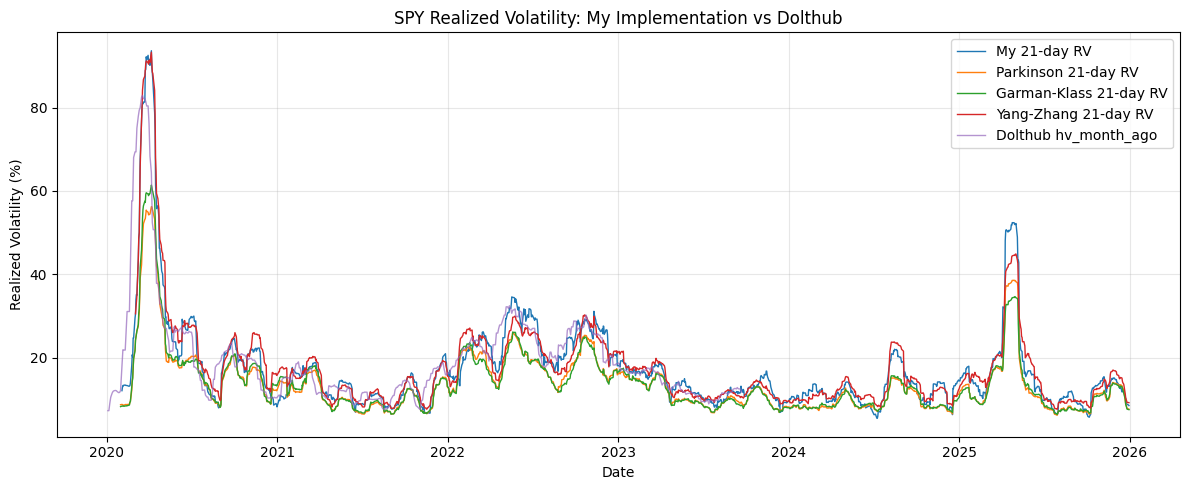

In [7]:
from src.rv_estimators import close_to_close_rv, parkinson_rv, garman_klass_rv, yang_zhang_rv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")

rv_21 = close_to_close_rv(sp["Close"], window=21)
park_rv_21 = parkinson_rv(sp['High'], sp['Low'], window=21)
klass_rv_21 = garman_klass_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)
yang_zhang_rv_21 = yang_zhang_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)

vh = vh.set_index("date").sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rv_21.index, rv_21 * 100, linewidth=1, label="My 21-day RV")
ax.plot(park_rv_21.index, park_rv_21 * 100, linewidth=1, label="Parkinson 21-day RV")
ax.plot(klass_rv_21.index, klass_rv_21 * 100, linewidth=1, label="Garman-Klass 21-day RV")
ax.plot(yang_zhang_rv_21.index, yang_zhang_rv_21 * 100, linewidth=1, label="Yang-Zhang 21-day RV")
ax.plot(vh.index, vh["hv_month_ago"].shift(-21) * 100, linewidth=1, label="Dolthub hv_month_ago", alpha=0.7)
ax.set_title("SPY Realized Volatility: My Implementation vs Dolthub")
ax.set_xlabel("Date")
ax.set_ylabel("Realized Volatility (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
from src.rv_estimators import close_to_close_rv, parkinson_rv, garman_klass_rv, yang_zhang_rv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

prices = pd.read_parquet(DATA_DIR / "spy_prices.parquet")  # adjust path as needed

window = 21

estimators = {
    "Close-to-Close": close_to_close_rv(prices["Close"], window=window),
    "Parkinson":      parkinson_rv(prices["High"], prices["Low"], window=window),
    "Garman-Klass":   garman_klass_rv(prices["High"], prices["Low"], prices["Open"], prices["Close"], window=window),
    "Yang-Zhang":     yang_zhang_rv(prices["High"], prices["Low"], prices["Open"], prices["Close"], window=window),
}

future_rv = close_to_close_rv(prices["Close"], window=window).shift(-window)

print(f"Forward-looking MSE ({window}-day horizon)")
print("-" * 45)

results = {}
for name, hist_rv in estimators.items():
    valid = hist_rv.notna() & future_rv.notna()
    errors = hist_rv[valid] - future_rv[valid]
    mse = (errors ** 2).mean()
    rmse = np.sqrt(mse)
    bias = errors.mean()
    results[name] = {"MSE": mse, "RMSE": rmse, "Bias": bias, "N": valid.sum()}
    print(f"{name:18s}  MSE: {mse:.6f}   RMSE: {rmse*100:.2f}%   Bias: {bias*100:+.2f}%   N: {valid.sum()}")

# Optional: rank them
print("\nRanking (lower MSE = better predictor):")
ranked = sorted(results.items(), key=lambda x: x[1]["MSE"])
for i, (name, stats) in enumerate(ranked, 1):
    print(f"  {i}. {name}")

Forward-looking MSE (21-day horizon)
---------------------------------------------
Close-to-Close      MSE: 0.015066   RMSE: 12.27%   Bias: +0.07%   N: 1465
Parkinson           MSE: 0.012884   RMSE: 11.35%   Bias: -3.67%   N: 1466
Garman-Klass        MSE: 0.012981   RMSE: 11.39%   Bias: -3.64%   N: 1466
Yang-Zhang          MSE: 0.010702   RMSE: 10.34%   Bias: +1.07%   N: 1445

Ranking (lower MSE = better predictor):
  1. Yang-Zhang
  2. Parkinson
  3. Garman-Klass
  4. Close-to-Close
